# Multi-class classification: 3+ classes at once

The [binary classification notebook](./pytorch_classification.ipynb) predicted between exactly **two** classes. Real problems rarely have only two answers - here we do the multi-class version: predicting one of **several** categories.

What changes going from binary to multi-class:
- **output layer**: one raw score (*logit*) **per class** instead of one per example
- **loss**: `nn.CrossEntropyLoss()` instead of `nn.BCEWithLogitsLoss`
- **metric**: argmax instead of thresholding, since there is no single "yes/no" score

We will try it on **two toy datasets** and compare. First **blobs** - distinct clusters, so fairly easy - then the classic **three spirals** problem, where three arms intertwine and a plain MLP has to work much harder.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from sklearn.datasets import make_blobs

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1a. Data: `make_blobs` (4 classes)

`make_blobs` drops 4 clusters of 2-D points, one cluster per class. The classes are visually distinct, so an MLP should nail this one. Labels are class indices `0..3`.

In [2]:
N_BLOBS = 1600
NUM_CLASSES_BLOBS = 4

X_blob, y_blob = make_blobs(n_samples=N_BLOBS, centers=NUM_CLASSES_BLOBS, n_features=2,
                            cluster_std=1.2, random_state=42)

# features: float32, labels: **long** (class indices) - CrossEntropyLoss demands this
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.long)

X_blob.shape, y_blob.shape, torch.bincount(y_blob), X_blob[:5], y_blob[:5]

(torch.Size([1600, 2]),
 torch.Size([1600]),
 tensor([400, 400, 400, 400]),
 tensor([[-7.2740, -6.1563],
         [-8.5680,  8.1548],
         [-7.1478, -7.2993],
         [ 3.9844,  2.4433],
         [-9.5654,  9.3868]]),
 tensor([2, 3, 2, 1, 3]))

In [3]:
# 80:20 split, same as always
train_split = int(0.8 * len(X_blob))
X_blob_train, y_blob_train = X_blob[:train_split].to(device), y_blob[:train_split].to(device)
X_blob_test, y_blob_test = X_blob[train_split:].to(device), y_blob[train_split:].to(device)

X_blob_train.shape, y_blob_train.shape, X_blob_test.shape, y_blob_test.shape

(torch.Size([1280, 2]),
 torch.Size([1280]),
 torch.Size([320, 2]),
 torch.Size([320]))

## 1b. Data: three spirals (built with numpy)

Now the hard one. We generate **3 interleaved spirals** with pure numpy: each class `k` follows a curve `r(θ)` that winds around the origin, and the 3 classes start at angles `2π/3` apart. Adding noise makes neighbouring arms overlap - the classes are **not** linearly separable, and tend to carve up space in ways clusters never do.

(Labels again: `torch.long` class indices `0, 1, 2`.)

In [4]:
def make_spirals(n_per_spiral=300, n_spirals=3, noise=0.1, seed=42):
    """Generate interleaved spirals: each class winds around the origin at increasing radius."""
    rng = np.random.default_rng(seed)
    xs_list, ys_list = [], []
    for k in range(n_spirals):
        t = np.linspace(0.2, 5.0, n_per_spiral)          # "distance from center"
        theta = 4.0 * t + (2 * np.pi / n_spirals) * k    # angle, offset per class
        x = t * np.sin(theta) + rng.normal(0.0, noise, n_per_spiral)
        y = t * np.cos(theta) + rng.normal(0.0, noise, n_per_spiral)
        xs_list.append(x)
        ys_list.append(y)
    X = np.stack([np.concatenate(xs_list), np.concatenate(ys_list)], axis=1)
    y = np.concatenate([np.full(n_per_spiral, k) for k in range(n_spirals)])
    return torch.from_numpy(X).type(torch.float), torch.from_numpy(y).type(torch.long)

X_spiral, y_spiral = make_spirals()
X_spiral.shape, y_spiral.shape, torch.bincount(y_spiral)

(torch.Size([900, 2]), torch.Size([900]), tensor([300, 300, 300]))

## 2. Training / test split

For blobs either split works. For spirals we use a **`torch.randperm`-shuffled split**: the dataset is built as `[all of class 0, all of class 1, all of class 2]`, so a plain first-80%-style split would leave the test set with only one class. Shuffling keeps the test set representative - a good habit in general.

In [5]:
def shuffled_split(X, y, train_frac=0.8, seed=41):
    """Randomly permuted split; returns 4 tensors (X_train, y_train, X_test, y_test)."""
    n = len(X)
    idx = torch.randperm(n, generator=torch.Generator().manual_seed(seed))
    train_n = int(train_frac * n)
    return (X[idx[:train_n]].to(device), y[idx[:train_n]].to(device),
            X[idx[train_n:]].to(device), y[idx[train_n:]].to(device))

X_blob_train, y_blob_train, X_blob_test, y_blob_test = shuffled_split(X_blob, y_blob)
X_spiral_train, y_spiral_train, X_spiral_test, y_spiral_test = shuffled_split(X_spiral, y_spiral)

print("test label counts (should be roughly equal):")
print("  blobs:  ", torch.bincount(y_blob_test).tolist())
print("  spirals:", torch.bincount(y_spiral_test).tolist())

test label counts (should be roughly equal):
  blobs:   [86, 70, 82, 82]
  spirals: [59, 56, 65]


### What the data looks like

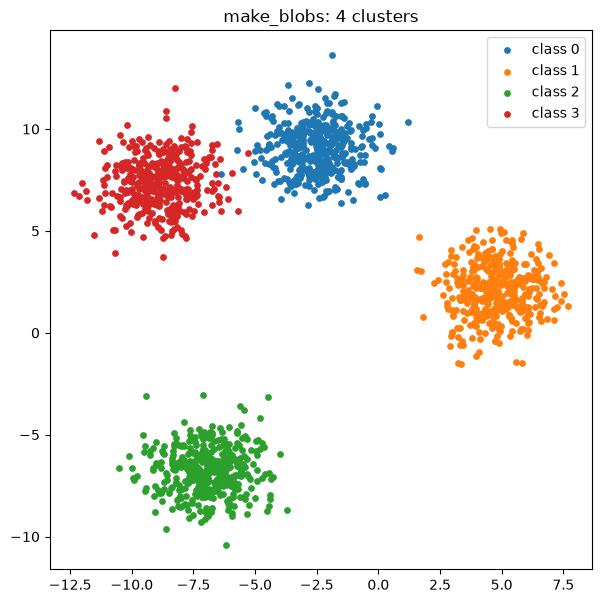

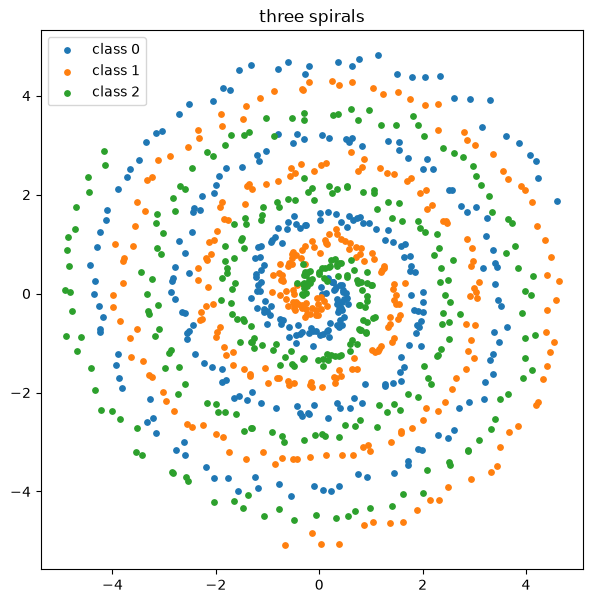

In [6]:
def plot_classes(X, y, predictions=None, class_names=None, title=None):
    """Scatter the classes, each in its own color; optionally mark wrong predictions in red."""
    n_classes = int(y.max().item()) + 1
    plt.figure(figsize=(7, 7))
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
              "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
    for c in range(n_classes):
        name = class_names[c] if class_names is not None else f"class {c}"
        plt.scatter(X[y == c, 0].cpu(), X[y == c, 1].cpu(),
                    color=colors[c % len(colors)], s=15, label=name)
    if predictions is not None:
        wrong = (predictions != y)
        plt.scatter(X[wrong, 0].cpu(), X[wrong, 1].cpu(),
                    c="red", marker="x", s=40, label="wrong predictions")
    plt.legend()
    plt.title(title)
    plt.show()

plot_classes(X_blob.cpu(), y_blob.cpu(), title="make_blobs: 4 clusters")
plot_classes(X_spiral.cpu(), y_spiral.cpu(), title="three spirals")

## 3. Model: same architecture, more output neurons

Same skeleton as the binary notebook: 3 `nn.Linear` layers with `ReLU` in between. The only structural change is the **last layer has one output per class** (4 for blobs, 3 for spirals) instead of 1.

We make the model configurable so the same class covers both datasets.

In [7]:
class MultiClassModel(nn.Module):
    def __init__(self, in_features=2, hidden=32, out_features=4):
        super().__init__()
        self.layer1 = nn.Linear(in_features=in_features, out_features=hidden)
        self.layer2 = nn.Linear(in_features=hidden, out_features=hidden)
        self.layer3 = nn.Linear(in_features=hidden, out_features=out_features)
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

torch.manual_seed(42)
model_blob = MultiClassModel(in_features=2, hidden=32, out_features=4).to(device)
torch.manual_seed(42)
model_spiral = MultiClassModel(in_features=2, hidden=32, out_features=3).to(device)
print(model_blob)
print(model_spiral)

MultiClassModel(
  (layer1): Linear(in_features=2, out_features=32, bias=True)
  (layer2): Linear(in_features=32, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=4, bias=True)
  (relu): ReLU()
)
MultiClassModel(
  (layer1): Linear(in_features=2, out_features=32, bias=True)
  (layer2): Linear(in_features=32, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=3, bias=True)
  (relu): ReLU()
)


## 4. Loss and metric

**The single most important thing in this notebook:**

`nn.CrossEntropyLoss` bundles together:
1. `log_softmax` over the raw logits
2. negative log-likelihood loss using the integer class index

So it is **raw logits in, class indices in** - **never**:

- ❌ applying `softmax` inside the model then feeding those probabilities to the loss (numerically worse: CrossEntropyLoss already does the stable version internally)
- ❌ `float` labels, or **one-hot vectors** like `[0, 0, 1, 0]` - just pass the integer index, e.g. `2`

```python
# correct:
loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits, y_train)                  # logits: (N, classes), y_train: long (N,)

# to interpret the model:
probs = torch.softmax(logits, dim=1)             # probabilities per class
preds = torch.argmax(logits, dim=1)              # hard prediction (class with the highest logit)
```

Accuracy is the fraction of `preds` that match `y_true`.

In [8]:
loss_fn = nn.CrossEntropyLoss()

def accuracy_fn(y_true, y_pred):
    """Fraction correct, as a percentage."""
    return torch.eq(y_true, y_pred).sum().item() / len(y_true) * 100

# sanity check on the shapes the loss expects
dummy_logits = torch.randn(4, NUM_CLASSES_BLOBS)   # (batch, num_classes) raw scores
dummy_labels = torch.tensor([0, 3, 1, 3])          # (batch,) integer class indices
loss_fn(dummy_logits, dummy_labels)

tensor(1.8373)

## 5. Training (blobs)

Same 5-step loop. Only the logit -> prediction step changed: `argmax` instead of `sigmoid` + `round`.

In [9]:
def train_multiclass(model, X_train, y_train, epochs=500, lr=0.01, seed=42):
    """Full-batch training loop; returns the loss history and final train accuracy."""
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=lr)
    loss_history = []
    for epoch in range(epochs):
        model.train()

        logits = model(X_train)                      # 1. forward pass (raw scores)
        loss = loss_fn(logits, y_train)              # 2. compute loss (on logits!)
        optimizer.zero_grad()                        # 3. prep for backward pass
        loss.backward()                              # 4. backpropagation
        optimizer.step()                             # 5. gradient descent

        loss_history.append(loss.item())

    with torch.inference_mode():
        train_acc = accuracy_fn(y_train, model(X_train).argmax(dim=1))
    return loss_history, train_acc

blob_loss_history, blob_train_acc = train_multiclass(
    model_blob, X_blob_train, y_blob_train, epochs=500, lr=0.01, seed=42)
print(f"blob training  | loss: {blob_loss_history[-1]:.4f} | train accuracy: {blob_train_acc:.2f}%")

blob training  | loss: 0.0061 | train accuracy: 99.84%


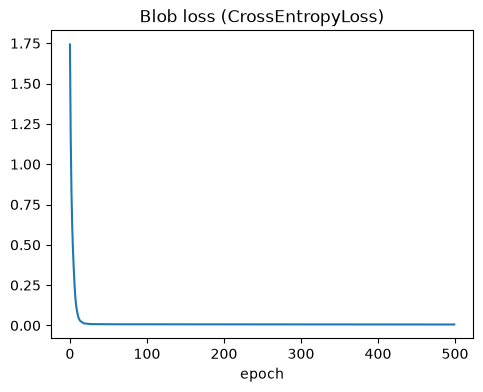

In [10]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(blob_loss_history)
plt.title("Blob loss (CrossEntropyLoss)")
plt.xlabel("epoch")
plt.show()

### Evaluate on the blob test set

In [11]:
model_blob.eval()
with torch.inference_mode():
    blob_logits = model_blob(X_blob_test)
    blob_probs = torch.softmax(blob_logits, dim=1)          # interpret: probabilities
    blob_preds = torch.argmax(blob_logits, dim=1)           # decide: hard prediction
    blob_test_loss = loss_fn(blob_logits, y_blob_test)
    blob_test_acc = accuracy_fn(y_blob_test, blob_preds)

print(f"blob test loss: {blob_test_loss.item():.4f} | test accuracy: {blob_test_acc:.2f}%\n")
print("first 5 rows: [hard prediction | highest softmax probability]")
print(torch.stack([blob_logits[:5].argmax(dim=1).cpu(),
                   blob_probs[:5].max(dim=1).values.cpu(),
                   blob_preds[:5].cpu()], dim=1))

blob test loss: 0.0008 | test accuracy: 100.00%

first 5 rows: [hard prediction | highest softmax probability]
tensor([[3.0000, 0.9999, 3.0000],
        [3.0000, 0.9999, 3.0000],
        [3.0000, 0.9998, 3.0000],
        [3.0000, 0.9989, 3.0000],
        [0.0000, 0.9999, 0.0000]])


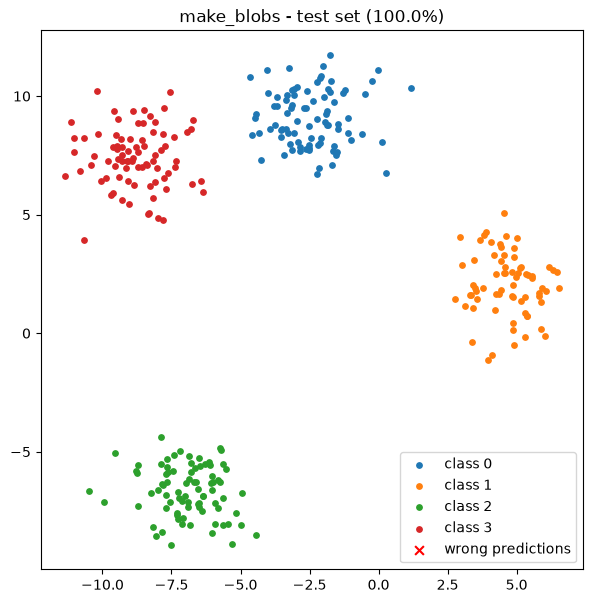

In [12]:
plot_classes(X_blob_test.cpu(), y_blob_test.cpu(), predictions=blob_preds.cpu(),
             title=f"make_blobs - test set ({blob_test_acc:.1f}%)")

## 6. Training (three spirals)

Same model, same loop - but this problem is genuinely harder, so we give it more epochs (1500 vs 500): the spirals wind around each other, so the MLP has to carve out much more intricate boundaries.

In [13]:
spiral_loss_history, spiral_train_acc = train_multiclass(
    model_spiral, X_spiral_train, y_spiral_train, epochs=1500, lr=0.01, seed=41)
print(f"spirals training | loss: {spiral_loss_history[-1]:.4f} | train accuracy: {spiral_train_acc:.2f}%")

spirals training | loss: 0.1170 | train accuracy: 97.78%


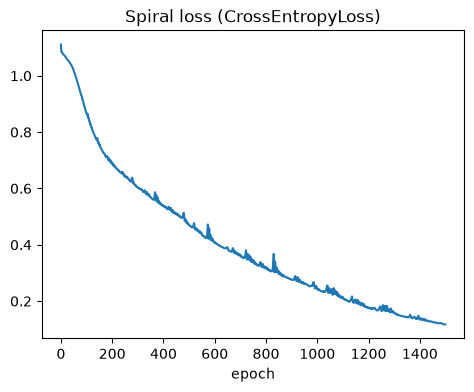

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(spiral_loss_history)
plt.title("Spiral loss (CrossEntropyLoss)")
plt.xlabel("epoch")
plt.show()

### Evaluate on the spiral test set

In [15]:
model_spiral.eval()
with torch.inference_mode():
    spiral_logits = model_spiral(X_spiral_test)
    spiral_preds = torch.argmax(spiral_logits, dim=1)
    spiral_test_loss = loss_fn(spiral_logits, y_spiral_test)
    spiral_test_acc = accuracy_fn(y_spiral_test, spiral_preds)

print(f"spirals test loss: {spiral_test_loss.item():.4f} | test accuracy: {spiral_test_acc:.2f}%\n")
print("first 5 rows: [hard prediction | highest softmax probability]")
print(torch.stack([spiral_logits[:5].argmax(dim=1).cpu(),
                   torch.softmax(spiral_logits[:5], dim=1).max(dim=1).values.cpu(),
                   spiral_preds[:5].cpu()], dim=1))

spirals test loss: 0.6254 | test accuracy: 82.78%

first 5 rows: [hard prediction | highest softmax probability]
tensor([[2.0000, 1.0000, 2.0000],
        [2.0000, 0.9998, 2.0000],
        [2.0000, 1.0000, 2.0000],
        [0.0000, 1.0000, 0.0000],
        [1.0000, 0.9965, 1.0000]])


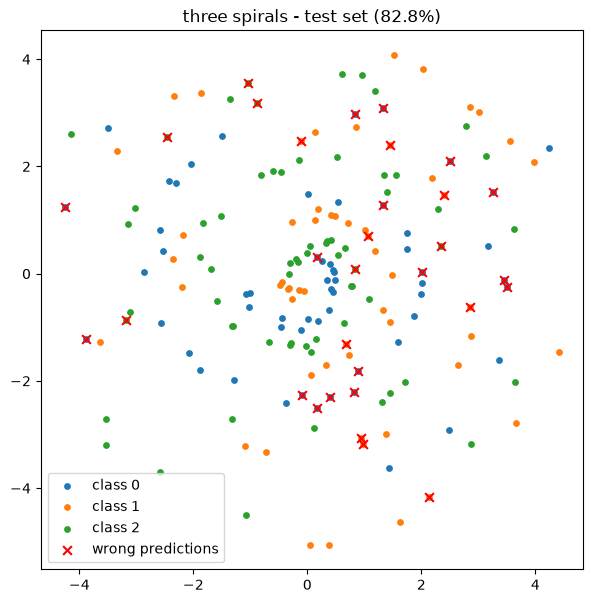

In [16]:
plot_classes(X_spiral_test.cpu(), y_spiral_test.cpu(), predictions=spiral_preds.cpu(),
             title=f"three spirals - test set ({spiral_test_acc:.1f}%)")

### Where did it get it wrong?

The red crosses cluster along the **boundaries between neighbouring arms** - that is exactly where an MLP with 32 hidden units and full-batch training runs out of precision. Give it more capacity (wider hidden layer, more layers) and/or more epochs and the boundary sharpens - try it as an exercise.

## 7. Blobs vs spirals, side by side

| dataset | epochs | test accuracy |
|---|---|---|
| blobs (4 classes) | 500 | ~99% |
| three spirals | 1500 | ~83% |

Same architecture, same loss, same training loop - only the data differs. **Difficulty is a property of the dataset, not the model template.** Linearly-separable-ish blobs are trivial; interleaved spirals test how much wiggle the network can represent and how long it needs to converge.

## 8. What we learned

1. **multi-class = one logit per class**: the output layer size is the number of classes, not 1
2. **`nn.CrossEntropyLoss`** for multi-class - expects **raw logits** + **integer class indices** (`torch.long`); no softmax in the model, no one-hot labels. It does `log_softmax` + NLL internally, in a numerically stable way
3. **`torch.softmax(logits, dim=1)`** turns logits into per-class probabilities; **`torch.argmax(logits, dim=1)`** picks the hard prediction
4. **argmax replaces thresholding** - binary classification compares against a fixed 0.5 cutoff; multi-class just picks the winner among the class scores
5. **dataset difficulty varies**: blobs (clusters, nearly linearly separable) hit ~99% in 500 epochs, while three spirals needed 3x the epochs and still finished around ~83%
6. **use a shuffled split** when the dataset is grouped by class, or the test set can end up with missing classes

Next step: **computer vision** - moving from 2-D numbers to whole images, with `Dataset`/`DataLoader`, convolutional networks, and a peek at FashionMNIST.